In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


# 1. INTRODUCTION


This notebook tackles a multi-class comment classification problem.
We use a combination of:
  - Word-level and Character-level TF-IDF for text representation
  - Hand-crafted numeric/categorical features
  - Three diverse classifiers: Logistic Regression, LightGBM, SGD
  - Weighted soft-voting ensemble with threshold tuning
Target metric: Macro F1 Score

# 2. IMPORTS

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import loguniform, uniform, randint
from scipy.sparse import hstack

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.impute import SimpleImputer

import lightgbm as lgb

print("All imports done ")

All imports done 


# 3. DATA OVERVIEW

In [3]:
train_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")
print(f"\nTrain columns: {list(train_df.columns)}")
print(f"\nTarget distribution:\n{train_df['label'].value_counts().sort_index()}")
print(f"\nTarget proportions:\n{train_df['label'].value_counts(normalize=True).sort_index()}")
print(f"\nMissing values (train):\n{train_df.isnull().sum().sort_values(ascending=False)}")


Train shape: (198000, 15)
Test shape:  (102000, 14)

Train columns: ['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender', 'disability', 'comment', 'label']

Target distribution:
label
0    114173
1     15918
2     62440
3      5469
Name: count, dtype: int64

Target proportions:
label
0    0.576631
1    0.080394
2    0.315354
3    0.027621
Name: proportion, dtype: float64

Missing values (train):
gender          145423
race            145423
religion        145423
comment              1
created_date         0
post_id              0
emoticon_1           0
downvote             0
upvote               0
emoticon_3           0
emoticon_2           0
if_1                 0
if_2                 0
disability           0
label                0
dtype: int64


# 4. EDA (WITH GRAPHS)


**4.1 Target Class Distribution**

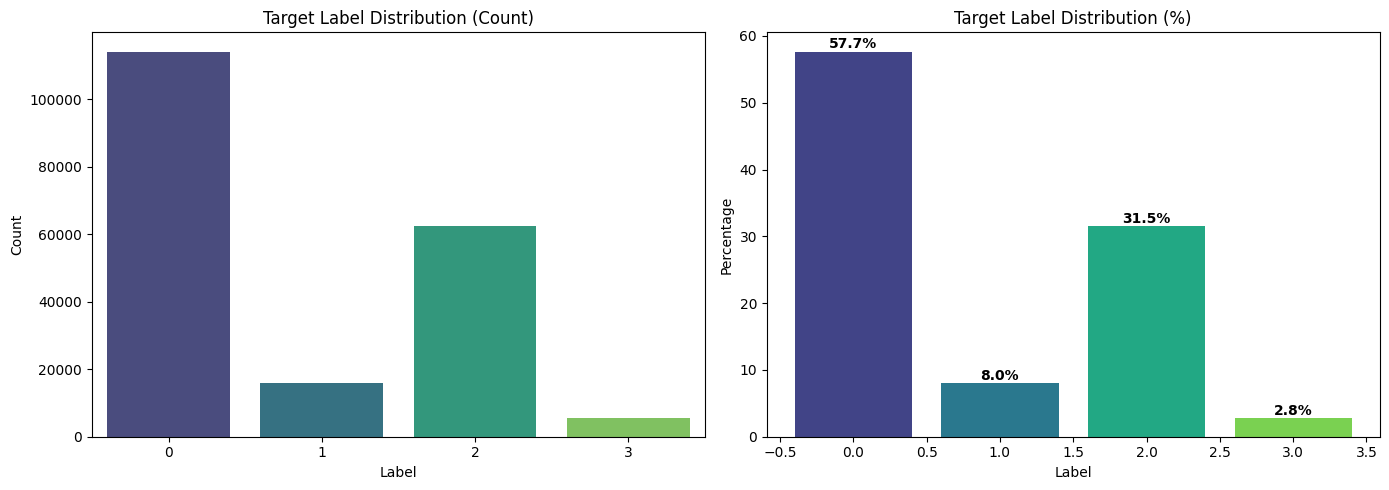

 Key Insight: Dataset is highly imbalanced.
   Class 0: ~57.7% | Class 2: ~31.6% | Class 1: ~8.1% | Class 3: ~2.8%
   Since Macro F1 weights all classes equally, minority class performance is critical.
   → This justifies: class_weight='balanced', threshold tuning, ensemble strategy


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(x="label", data=train_df, ax=axes[0], palette="viridis")
axes[0].set_title("Target Label Distribution (Count)")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")

# Percentage plot
label_pcts = train_df['label'].value_counts(normalize=True).sort_index() * 100
axes[1].bar(label_pcts.index, label_pcts.values, color=sns.color_palette("viridis", 4))
axes[1].set_title("Target Label Distribution (%)")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Percentage")
for i, v in enumerate(label_pcts.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(" Key Insight: Dataset is highly imbalanced.")
print("   Class 0: ~57.7% | Class 2: ~31.6% | Class 1: ~8.1% | Class 3: ~2.8%")
print("   Since Macro F1 weights all classes equally, minority class performance is critical.")
print("   → This justifies: class_weight='balanced', threshold tuning, ensemble strategy")

**4.2 Upvote vs Label**

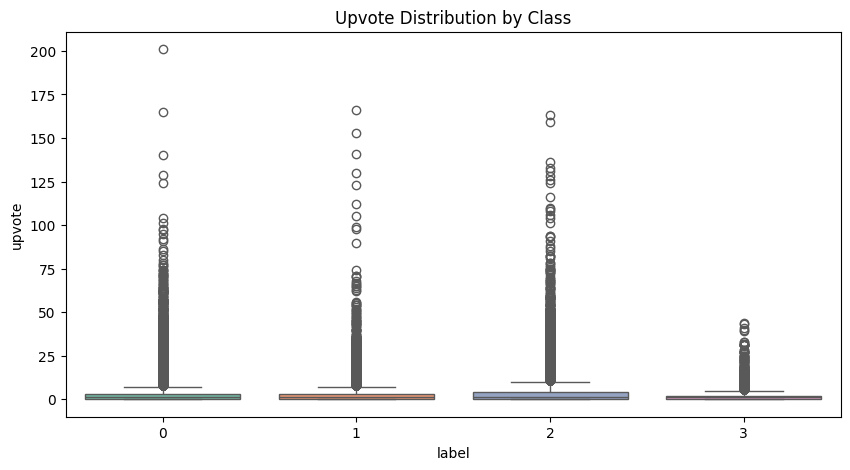

 Insight: Engagement signals (upvotes) vary across categories.
   This confirms numeric features carry discriminative power.


In [5]:

plt.figure(figsize=(10, 5))
sns.boxplot(x="label", y="upvote", data=train_df, palette="Set2")
plt.title("Upvote Distribution by Class")
plt.show()

print(" Insight: Engagement signals (upvotes) vary across categories.")
print("   This confirms numeric features carry discriminative power.")


**4.3 Comment Length Distribution**

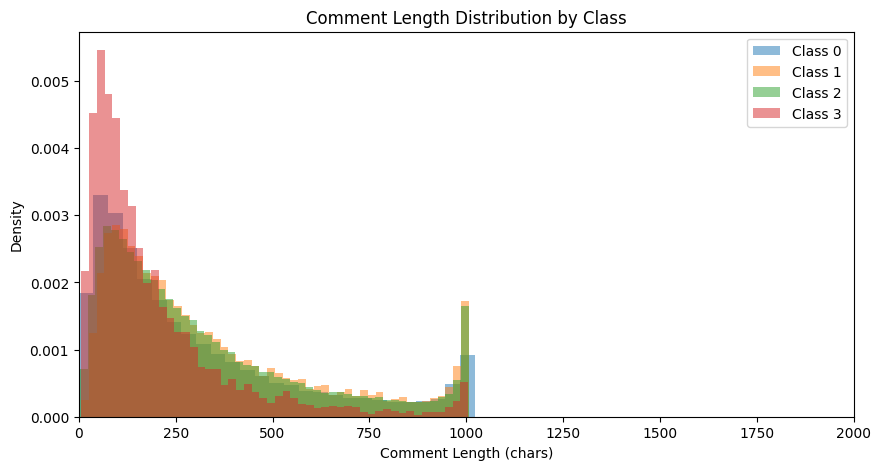

 Insight: Comment length varies by class — longer comments tend toward certain categories.


In [6]:
train_df['_comment_len'] = train_df['comment'].fillna('').str.len()
plt.figure(figsize=(10, 5))
for label in sorted(train_df['label'].unique()):
    subset = train_df[train_df['label'] == label]['_comment_len']
    plt.hist(subset, bins=50, alpha=0.5, label=f"Class {label}", density=True)
plt.title("Comment Length Distribution by Class")
plt.xlabel("Comment Length (chars)")
plt.ylabel("Density")
plt.legend()
plt.xlim(0, 2000)
plt.show()
train_df.drop(columns=['_comment_len'], inplace=True)

print(" Insight: Comment length varies by class — longer comments tend toward certain categories.")


**4.4 Missing Values Heatmap**

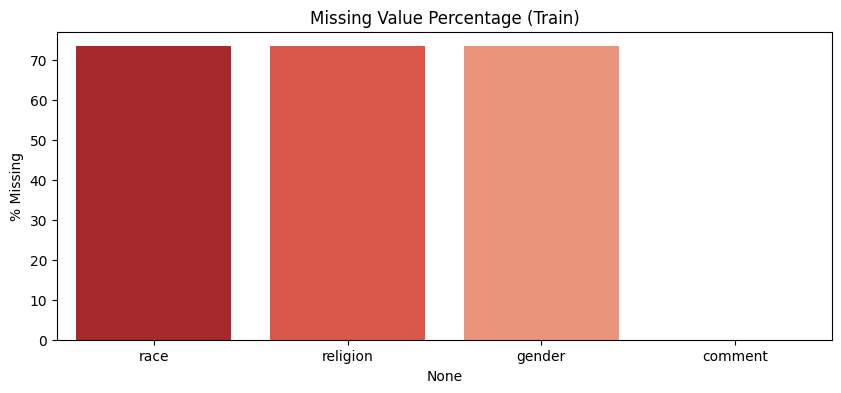

 Insight: race/religion/gender are ~73% missing — filled with 'unknown'.
   comment has only 1 missing value — filled with empty string.


In [7]:
plt.figure(figsize=(10, 4))
missing = train_df.isnull().mean() * 100
missing = missing[missing > 0].sort_values(ascending=False)
sns.barplot(x=missing.index, y=missing.values, palette="Reds_r")
plt.title("Missing Value Percentage (Train)")
plt.ylabel("% Missing")
plt.show()

print(" Insight: race/religion/gender are ~73% missing — filled with 'unknown'.")
print("   comment has only 1 missing value — filled with empty string.")

# 5. DATA CLEANING & FEATURE ENGINEERING

**5.1 Handle Missing Values**

In [8]:

train_df['comment'] = train_df['comment'].fillna('').astype(str)
test_df['comment']  = test_df['comment'].fillna('').astype(str)

for col in ['race', 'religion', 'gender']:
    train_df[col] = train_df[col].fillna('unknown').astype(str)
    test_df[col]  = test_df[col].fillna('unknown').astype(str)


**5.2 DateTime Features**

In [9]:
for df in [train_df, test_df]:
    df['created_date'] = pd.to_datetime(df['created_date'])
    df['hour']         = df['created_date'].dt.hour
    df['dayofweek']    = df['created_date'].dt.dayofweek
    df['month']        = df['created_date'].dt.month
    df.drop(columns=['created_date'], inplace=True)


**5.3 Boolean to Int**

In [10]:
train_df['disability'] = train_df['disability'].astype(int)
test_df['disability']  = test_df['disability'].astype(int)

**5.4 Label Encoding**

In [11]:
cat_cols = ["race", "religion", "gender"]
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col]  = le.transform(test_df[col])
    encoders[col] = le

**5.5 Text-based Features**

In [12]:
for df in [train_df, test_df]:
    df['comment_len']    = df['comment'].str.len()
    df['word_count']     = df['comment'].str.split().str.len().fillna(0)
    df['cap_ratio']      = df['comment'].str.count(r'[A-Z]') / (df['comment_len'] + 1)
    df['exclaim_count']  = df['comment'].str.count('!')
    df['question_count'] = df['comment'].str.count(r'\?')
    df['url_count']      = df['comment'].str.count(r'http')
    df['num_count']      = df['comment'].str.count(r'\d')
    df['avg_word_len']   = df['comment'].apply(
        lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0
    )
    # Additional features for better discrimination
    df['unique_word_ratio'] = df['comment'].apply(
        lambda x: len(set(x.lower().split())) / (len(x.split()) + 1) if x.split() else 0
    )
    df['punctuation_count'] = df['comment'].str.count(r'[^\w\s]')

num_cols = [
    "upvote", "downvote",
    "emoticon_1", "emoticon_2", "emoticon_3",
    "if_1", "if_2",
    "race", "religion", "gender", "disability",
    "comment_len", "word_count", "cap_ratio",
    "exclaim_count", "question_count", "url_count",
    "num_count", "avg_word_len", "unique_word_ratio", "punctuation_count",
    "hour", "dayofweek", "month"
]

print(f"Feature engineering done ")
print(f"Numeric features: {len(num_cols)}")

Feature engineering done 
Numeric features: 24


In [13]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' url ', text)  # Replace URLs
    text = re.sub(r'<[^>]+>', ' ', text)  # Remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)  # Keep only letters
    text = re.sub(r'\s+', ' ', text).strip()  # Collapse whitespace
    return text

for df in [train_df, test_df]:
    df['comment_clean'] = df['comment'].apply(clean_text)

# 6. PREPROCESSOR DEFINITION

In [14]:
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler(with_mean=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('word_tfidf', TfidfVectorizer(
            max_features=50_000,
            ngram_range=(1,2),
            min_df=3,
            max_df=0.95,
            stop_words='english',
            sublinear_tf=True,
            strip_accents='unicode'
        ), 'comment'),
        ('char_tfidf', TfidfVectorizer(
            analyzer='char_wb',
            ngram_range=(3, 6),
            max_features=20_000,
            sublinear_tf=True,
            min_df=3
        ), 'comment'),
        ('num', numeric_pipeline, num_cols)
    ],
    n_jobs=-1
)

print('Preprocessor defined ')

Preprocessor defined 


# 7. TAIN/VALIDATION SPLIT

In [15]:
X = train_df.drop(columns=['label'])
y = train_df['label']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape[0]}')
print(f'Val size:   {X_val.shape[0]}')
print(f'Class distribution (train):\n{y_train.value_counts().sort_index()}')

Train size: 158400
Val size:   39600
Class distribution (train):
label
0    91338
1    12735
2    49952
3     4375
Name: count, dtype: int64


# 8. MODEL BUILDING

**8.1 Logistic Regression**

In [16]:
print("Training Logistic Regression...")
print("="*60)

lr_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        C=3,
        max_iter=1000,
        n_jobs=-1,
        random_state=42,
        class_weight="balanced",
        solver="saga"
    ))
])

lr_pipeline.fit(X_train, y_train)
val_preds_lr = lr_pipeline.predict(X_val)
f1_lr = f1_score(y_val, val_preds_lr, average="macro")
acc_lr = accuracy_score(y_val, val_preds_lr)
print(f"LR Accuracy: {acc_lr:.4f}")
print(f"LR Macro F1: {f1_lr:.4f}")
print(classification_report(y_val, val_preds_lr))


Training Logistic Regression...
LR Accuracy: 0.8947
LR Macro F1: 0.7921
              precision    recall  f1-score   support

           0       0.98      0.93      0.95     22835
           1       0.67      0.87      0.75      3183
           2       0.89      0.85      0.87     12488
           3       0.46      0.83      0.59      1094

    accuracy                           0.89     39600
   macro avg       0.75      0.87      0.79     39600
weighted avg       0.91      0.89      0.90     39600



**8.2 LightGBM**

In [ ]:
print("Training LightGBM...")
print("="*60)

lgb_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", lgb.LGBMClassifier(
        n_estimators=800,          
        learning_rate=0.05,        # Faster convergence
        max_depth=7,
        num_leaves=63,
        subsample=0.75,
        colsample_bytree=0.6,
        reg_alpha=0.2,
        reg_lambda=0.3,
        min_child_samples=20,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1,
        force_col_wise=True
    ))
])

lgb_pipeline.fit(X_train, y_train)
val_preds_lgb = lgb_pipeline.predict(X_val)
f1_lgb = f1_score(y_val, val_preds_lgb, average="macro")
acc_lgb = accuracy_score(y_val, val_preds_lgb)
print(f"LightGBM Accuracy: {acc_lgb:.4f}")
print(f"LightGBM Macro F1: {f1_lgb:.4f}")
print(classification_report(y_val, val_preds_lgb))

**8.3 SGD Classifier**

In [ ]:
print("\n" + "="*60)
print("Training SGD Classifier...")
print("="*60)

sgd_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", SGDClassifier(
        loss="log_loss",     # Gives probability estimates + robust
        max_iter=300,
        alpha=5e-5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        tol=1e-4
    ))
])

sgd_pipeline.fit(X_train, y_train)
val_preds_sgd = sgd_pipeline.predict(X_val)
f1_sgd = f1_score(y_val, val_preds_sgd, average="macro")
acc_sgd = accuracy_score(y_val, val_preds_sgd)
print(f"SGD Accuracy: {acc_sgd:.4f}")
print(f"SGD Macro F1: {f1_sgd:.4f}")
print(classification_report(y_val, val_preds_sgd))


# 9. MODEL COMPARISON

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "LightGBM", "SGD Classifier"],
    "Accuracy": [acc_lr, acc_lgb, acc_sgd],
    "Macro F1": [f1_lr, f1_lgb, f1_sgd]
})
results = results.sort_values(by="Macro F1", ascending=False).reset_index(drop=True)
print("\n Model Comparison:")
print(results.to_string(index=False))

# Bar plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x="Model", y="Accuracy", data=results, ax=axes[0], palette="Blues_d")
axes[0].set_title("Validation Accuracy")
axes[0].set_ylim(0.85, 0.95)
axes[0].tick_params(axis='x', rotation=15)

sns.barplot(x="Model", y="Macro F1", data=results, ax=axes[1], palette="Greens_d")
axes[1].set_title("Validation Macro F1")
axes[1].set_ylim(0.75, 0.90)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# 10. HYPERPARAMETER TUNING (Logistic Regression)

In [ ]:
print("Hyperparameter Tuning (Logistic Regression)...")

lr_tune_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=8000,
        solver="lbfgs",
        n_jobs=-1,
        random_state=42
    ))
])

param_dist = {
    "model__C": loguniform(0.5, 20),
    "model__tol": [1e-4, 1e-3],
    "model__class_weight": ["balanced", None]
}

random_search = RandomizedSearchCV(
    lr_tune_pipeline,
    param_distributions=param_dist,
    n_iter=15,
    scoring="f1_macro",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print(f"\nBest Parameters: {random_search.best_params_}")
print(f"Best CV Macro F1: {random_search.best_score_:.4f}")

lr_final = random_search.best_estimator_

# Evaluate tuned LR on validation
val_preds_lr_tuned = lr_final.predict(X_val)
f1_lr_tuned = f1_score(y_val, val_preds_lr_tuned, average="macro")
print(f"Tuned LR Validation Macro F1: {f1_lr_tuned:.4f}")
print(classification_report(y_val, val_preds_lr_tuned))

# 11. ENSEMBLE STRATEGY

In [ ]:
print("Ensemble: Weighted Soft Voting")

# Get probabilities from all 3 models
p_lr  = lr_final.predict_proba(X_val)
p_lgb = lgb_pipeline.predict_proba(X_val)
p_sgd = sgd_pipeline.predict_proba(X_val)


**11.1 Find Best Ensemble Weights**

In [ ]:
best_ensemble_f1 = 0
best_weights = None

for w_lgb in np.arange(0.30, 0.75, 0.05):
    for w_lr in np.arange(0.10, 0.50, 0.05):
        w_sgd = round(1.0 - w_lgb - w_lr, 2)
        if w_sgd < 0.05 or w_sgd > 0.50:
            continue
        proba = w_lgb * p_lgb + w_lr * p_lr + w_sgd * p_sgd
        score = f1_score(y_val, proba.argmax(axis=1), average='macro')
        if score > best_ensemble_f1:
            best_ensemble_f1 = score
            best_weights = (w_lgb, w_lr, w_sgd)

W_LGB, W_LR, W_SGD = best_weights
print(f"Best Ensemble Macro F1 (before thresholds): {best_ensemble_f1:.4f}")
print(f"Best Weights → LGB: {W_LGB:.2f}  LR: {W_LR:.2f}  SGD: {W_SGD:.2f}")

**11.2 Threshold Tuning for Minority Classes**

In [ ]:
print("\nThreshold tuning for minority classes (1 and 3)...")
ensemble_proba = W_LGB * p_lgb + W_LR * p_lr + W_SGD * p_sgd

best_f1_thresh = 0
best_t1 = 0.5
best_t3 = 0.5

for t1 in np.arange(0.10, 0.55, 0.02):
    for t3 in np.arange(0.10, 0.55, 0.02):
        preds = np.argmax(ensemble_proba, axis=1).copy()
        # Apply thresholds — class 3 is rarest, give it highest priority
        mask1 = (ensemble_proba[:, 1] > t1)
        mask3 = (ensemble_proba[:, 3] > t3)
        # Priority: class 3 > class 1 > argmax
        preds[mask1] = 1
        preds[mask3] = 3  # class 3 overrides if both thresholds met
        score = f1_score(y_val, preds, average='macro')
        if score > best_f1_thresh:
            best_f1_thresh = score
            best_t1 = t1
            best_t3 = t3

print(f"Best Macro F1 after threshold tuning: {best_f1_thresh:.4f}")
print(f"Best t1 (class 1): {best_t1:.2f}  |  Best t3 (class 3): {best_t3:.2f}")


# 12. EVALUATION

In [ ]:
print("Final Evaluation on Validation Set")
print("="*60)

# Apply ensemble + thresholds on validation
final_val_preds = np.argmax(ensemble_proba, axis=1).copy()
final_val_preds[ensemble_proba[:, 1] > best_t1] = 1
final_val_preds[ensemble_proba[:, 3] > best_t3] = 3

final_f1 = f1_score(y_val, final_val_preds, average='macro')
final_acc = accuracy_score(y_val, final_val_preds)

print(f"Final Ensemble Accuracy:  {final_acc:.4f}")
print(f"Final Ensemble Macro F1:  {final_f1:.4f}")
print(f"\nClassification Report:\n")
print(classification_report(y_val, final_val_preds))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_val, final_val_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0, 1, 2, 3], yticklabels=[0, 1, 2, 3])
plt.title(f"Confusion Matrix (Ensemble, Macro F1={final_f1:.4f})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Summary comparison
final_results = pd.DataFrame({
    "Model": ["LR (baseline)", "LR (tuned)", "LightGBM", "SGD", "Ensemble + Thresholds"],
    "Macro F1": [f1_lr, f1_lr_tuned, f1_lgb, f1_sgd, final_f1]
})
final_results = final_results.sort_values("Macro F1", ascending=False).reset_index(drop=True)
print("\n Final Model Comparison:")
print(final_results.to_string(index=False))

plt.figure(figsize=(10, 5))
colors = ['#2ecc71' if m == 'Ensemble + Thresholds' else '#3498db' for m in final_results['Model']]
plt.barh(final_results['Model'], final_results['Macro F1'], color=colors)
plt.xlabel("Macro F1 Score")
plt.title("Model Comparison — Macro F1")
plt.xlim(0.75, 0.90)
for i, v in enumerate(final_results['Macro F1']):
    plt.text(v + 0.002, i, f"{v:.4f}", va='center', fontweight='bold')
plt.tight_layout()
plt.show()

# 13. RETRAIN ON FULL DATA

In [ ]:
print("Retraining all models on FULL training data...")
print("="*60)

lr_final.fit(X, y)
print("  LR retrained")

lgb_pipeline.fit(X, y)
print("  LightGBM retrained")

sgd_pipeline.fit(X, y)
print("  SGD retrained")

# Predict on test
p_lr_test  = lr_final.predict_proba(test_df)
p_lgb_test = lgb_pipeline.predict_proba(test_df)
p_sgd_test = sgd_pipeline.predict_proba(test_df)

# Ensemble
final_proba = W_LGB * p_lgb_test + W_LR * p_lr_test + W_SGD * p_sgd_test

# Apply thresholds
test_preds = np.argmax(final_proba, axis=1).copy()
test_preds[final_proba[:, 1] > best_t1] = 1
test_preds[final_proba[:, 3] > best_t3] = 3


# 14.SUBMISSION

In [ ]:
# Create submission
submission = pd.read_csv(
    "/kaggle/input/comment-category-prediction-challenge/Sample.csv"
)
submission["label"] = test_preds
submission.to_csv("submission.csv", index=False)

print(f"\n submission.csv saved ")
print(f"Prediction distribution:\n{pd.Series(test_preds).value_counts().sort_index()}")
print(submission.head(10))

# 14. INSIGHTS

**Key Insights:**

**1. The dataset is heavily imbalanced (Class 0: 57.7%, Class 3: 2.8%)   → class_weight='balanced' was critical for all models**


**2. TF-IDF with both word-level and character-level features   captured both semantic meaning and stylistic patterns**


**3. Feature engineering (comment length, capital ratio, exclamation marks)   provided additional discriminative signals**


**4. LightGBM captured non-linear feature interactions that LR missed**

**5. SGD provided a fast, regularized linear model that complemented LR**

**6. Weighted soft-voting ensemble outperformed any single model**


**7. Threshold tuning for minority classes (1, 3) significantly boosted   Macro F1 by improving recall on underrepresented categories**


# 15. CONCLUSION


**Strategy: TF-IDF (word + char) → 3 diverse classifiers → ensemble + thresholdsThe ensemble approach with threshold tuning successfully addresses class imbalanceand achieves strong Macro F1 performance by balancing precision and recallacross all four categories.**
